# 🔋 Processor-in-the-Loop (PiL) Simulation — Preview
**Simulasi Python** yang mereplikasi algoritma `main.cpp` secara penuh:
- **Coulomb Counting (CC)** — referensi tanpa koreksi
- **Extended Kalman Filter (EKF)** — estimasi SoC + tegangan
- **Ground Truth SoC** — Coulomb Counting sempurna (tanpa offset)

Model Baterai: **LiFePO4 1-RC Thevenin ECM** | Kapasitas: **20.80 Ah**

> ⚙️ Parameter EKF identik dengan `src/main.cpp` — hasil plot ini merepresentasikan performa yang diharapkan pada ESP32.

In [1]:
# ============================================================
# CELL 1: Import & Konfigurasi
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Gaya visual premium ──────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'axes.titlecolor':  '#f0f6fc',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.8,
    'legend.facecolor': '#21262d',
    'legend.edgecolor': '#30363d',
    'legend.labelcolor':'#c9d1d9',
    'text.color':       '#c9d1d9',
    'font.family':      'DejaVu Sans',
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.labelsize':   10,
})

# ── Path ke folder data ──────────────────────────────────────
DATA_DIR  = Path('data')

# ── Folder output gambar (terpisah dari notebook) ────────────
PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(exist_ok=True)

print('✅ Import selesai — siap simulasi!')
print(f'📁 Output gambar akan disimpan di: {PLOTS_DIR.resolve()}')

✅ Import selesai — siap simulasi!
📁 Output gambar akan disimpan di: C:\Users\zenaj\Documents\Courses\Sms 8\Simulasi-Cell-B\Simulasi Proccessor In the Loop\pil-soc\plots


In [2]:
# ============================================================
# CELL 2: Parameter Model Baterai (IDENTIK dengan main.cpp)
# ============================================================

# ── Kapasitas ────────────────────────────────────────────────
Q_AH      = 20.798555
Q_COULOMB = 74874.8   # A·s

# ── OCV-SoC LUT (21 titik, resolusi 5%) ─────────────────────
lut_soc_ocv = np.array([
    0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45,
    0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00
])
lut_ocv_val = np.array([
    2.6550, 3.0269, 3.1972, 3.2391, 3.2261, 3.2242, 3.2424, 3.2625,
    3.2758, 3.2835, 3.2871, 3.2880, 3.2878, 3.2884, 3.2917, 3.2958,
    3.2973, 3.3039, 3.3353, 3.4122, 3.5370
])

# ── ECM Parameter LUT (1-RC Thevenin) ───────────────────────
lut_soc_ecm = np.array([0.0, 0.090902, 0.204618, 0.318054, 0.431697,
                         0.545421, 0.659070, 0.772787, 0.886430])
lut_r0 = np.array([0.006050, 0.002800, 0.002800, 0.002899, 0.002700,
                    0.002400, 0.002899, 0.002199, 0.002800])
lut_r1 = np.array([0.009500, 0.002506, 0.002207, 0.002212, 0.002372,
                    0.002436, 0.002374, 0.002345, 0.002684])
lut_c1 = np.array([11281.15, 20591.86, 24841.48, 15061.40, 20897.75,
                    19607.70, 15177.97, 16580.74, 24189.08])

# ── Tuning EKF Noise ─────────────────────────────────────────
Q_NOISE_00 = 2e-6
Q_NOISE_11 = 1e-1
R_BASE     = 0.0001
R_REST     = 0.0001

# ── Rest Detection ───────────────────────────────────────────
REST_CURRENT_THRESH = 0.05   # A
REST_SETTLE_S       = 30     # detik

# ── Soft Deadband ────────────────────────────────────────────
DEADBAND_V = 0.001  # 1 mV

print('✅ Parameter model loaded!')
print(f'   Q_AH = {Q_AH:.4f} Ah  |  Q_COULOMB = {Q_COULOMB:.1f} A·s')
print(f'   Q_NOISE_00 = {Q_NOISE_00:.1e}  |  Q_NOISE_11 = {Q_NOISE_11:.1e}')
print(f'   R_BASE = {R_BASE}  |  R_REST = {R_REST}')

✅ Parameter model loaded!
   Q_AH = 20.7986 Ah  |  Q_COULOMB = 74874.8 A·s
   Q_NOISE_00 = 2.0e-06  |  Q_NOISE_11 = 1.0e-01
   R_BASE = 0.0001  |  R_REST = 0.0001


In [3]:
# ============================================================
# CELL 3: Fungsi Matematika (replika tepat dari main.cpp)
# ============================================================

def interpolate1D(x, x_data, y_data):
    """Piecewise linear interpolation — sama persis dengan main.cpp."""
    if x <= x_data[0]:  return y_data[0]
    if x >= x_data[-1]: return y_data[-1]
    for i in range(len(x_data) - 1):
        if x_data[i] <= x <= x_data[i+1]:
            t = (x - x_data[i]) / (x_data[i+1] - x_data[i])
            return y_data[i] + t * (y_data[i+1] - y_data[i])
    return y_data[0]

def get_OCV(soc):
    soc = np.clip(soc, 0.0, 1.0)
    return interpolate1D(soc, lut_soc_ocv, lut_ocv_val)

def get_dOCV_dSOC(soc):
    soc = np.clip(soc, 0.0, 1.0)
    h = 0.005
    soc_lo = max(soc - h, 0.0)
    soc_hi = min(soc + h, 1.0)
    dS = soc_hi - soc_lo
    if dS < 1e-6: return 0.0
    return (get_OCV(soc_hi) - get_OCV(soc_lo)) / dS

def run_CC_step(soc, I, dt):
    return np.clip(soc - (I * dt / Q_COULOMB), 0.0, 1.0)

def run_EKF_step(ekf_x, ekf_P, I, V_meas, dt, in_confirmed_rest):
    """Satu langkah EKF — replika identik dari main.cpp runEKFStep()."""
    soc_prev = np.clip(ekf_x[0], 0.0, 1.0)
    vc1_prev = ekf_x[1]

    R0  = max(interpolate1D(soc_prev, lut_soc_ecm, lut_r0), 0.0001)
    R1  = max(interpolate1D(soc_prev, lut_soc_ecm, lut_r1), 0.0001)
    C1  = max(interpolate1D(soc_prev, lut_soc_ecm, lut_c1), 1.0)
    tau = max(R1 * C1, 1e-6)

    # Time update
    soc_pred = np.clip(soc_prev - (I * dt / Q_COULOMB), 0.0, 1.0)
    alpha    = np.exp(-dt / tau) if dt > 0 else 1.0
    vc1_pred = alpha * vc1_prev + R1 * (1.0 - alpha) * I

    P_pred = np.array([
        [ekf_P[0,0] + Q_NOISE_00, 0.0],
        [0.0, alpha**2 * ekf_P[1,1] + Q_NOISE_11]
    ])

    # Measurement update
    OCV_pred  = get_OCV(soc_pred)
    dOCV_dSOC = get_dOCV_dSOC(soc_pred)
    V_pred    = OCV_pred - vc1_pred - I * R0

    h0 = abs(dOCV_dSOC) + 1e-4
    h1 = -1.0
    H  = np.array([h0, h1])

    # Dynamic R
    if in_confirmed_rest:
        R_dynamic = R_REST
    elif abs(I) < 0.05:
        R_dynamic = R_BASE / (abs(dOCV_dSOC) + 1e-3)
    else:
        R_dynamic = R_BASE / (abs(dOCV_dSOC) + 1e-4)
    R_dynamic = np.clip(R_dynamic, 0.0001, 10.0)

    # Innovation & Kalman gain
    S  = H @ P_pred @ H + R_dynamic
    S  = max(S, 1e-9)
    K  = P_pred @ H / S

    innov   = V_meas - V_pred
    K0_eff  = K[0] * (abs(innov) / DEADBAND_V) if abs(innov) < DEADBAND_V else K[0]

    ekf_x_new = ekf_x.copy()
    soc_correction = np.clip(K0_eff * innov, -0.10, 0.10)
    ekf_x_new[0] = np.clip(soc_pred + soc_correction, 0.0, 1.0)
    ekf_x_new[1] = np.clip(vc1_pred + K[1] * innov, -0.5, 0.5)

    # Joseph form covariance update
    I_KH = np.eye(2) - np.outer(np.array([K0_eff, K[1]]), H)
    ekf_P_new = I_KH @ P_pred @ I_KH.T + np.outer(np.array([K0_eff, K[1]]), np.array([K0_eff, K[1]])) * R_dynamic
    ekf_P_new = (ekf_P_new + ekf_P_new.T) / 2  # symmetry
    ekf_P_new[0,0] = max(ekf_P_new[0,0], 1e-10)
    ekf_P_new[1,1] = max(ekf_P_new[1,1], 1e-10)

    return ekf_x_new, ekf_P_new, V_pred

print('✅ Fungsi EKF/CC siap!')

✅ Fungsi EKF/CC siap!


In [4]:
# ============================================================
# CELL 4: Runner Simulasi Dataset (replika runDatasetTest)
# ============================================================

# Map nama file → SoC awal sebenarnya (identik main.cpp)
SOC_INIT_MAP = {
    'clean_h-charge_rest_60m.csv':                      0.00,
    'clean_h-DCC-4.4A-2.5V.csv':                        1.00,
    'clean_h-Dynamic_Profiling_(Urban Load).csv':        0.953,
    'clean_h-charging_7.33A-rest 2h.csv':               0.06,
    'clean_h-DCC_4.4A_2.5V-CCV_6.6_3.65V-DCC_4.4A_2.5V.csv': 0.01,
}

DATASET_LABEL = {
    'clean_h-charge_rest_60m.csv':                      'Charge + Rest 60m',
    'clean_h-DCC-4.4A-2.5V.csv':                        'DCC 4.4A–2.5V',
    'clean_h-Dynamic_Profiling_(Urban Load).csv':        'Dynamic Profiling (Urban)',
    'clean_h-charging_7.33A-rest 2h.csv':               'Charge 7.33A + Rest 2h',
    'clean_h-DCC_4.4A_2.5V-CCV_6.6_3.65V-DCC_4.4A_2.5V.csv': 'DCC–CCV–DCC',
}

def run_dataset(filename: str, offset_pct: float) -> dict:
    """Simulasi penuh satu dataset dengan satu nilai offset error."""
    fpath = DATA_DIR / filename
    df    = pd.read_csv(fpath)

    times    = df['Time(S)'].values
    currents = df['Dir_Cur(A)'].values   # sudah signed dari preprocess.py
    voltages = df['Vol(V)'].values

    # Inisialisasi
    soc_true_init = SOC_INIT_MAP.get(filename, 0.5)
    soc_algo_start = (soc_true_init + offset_pct) if soc_true_init < 0.10 else (soc_true_init - offset_pct)
    soc_algo_start = np.clip(soc_algo_start, 0.0, 1.0)

    soc_true  = soc_true_init
    soc_cc    = soc_algo_start
    ekf_x     = np.array([soc_algo_start, 0.0])
    ekf_P     = np.array([
        [(abs(offset_pct) * 50.0) + 0.01, 0.0],
        [0.0, 0.001]
    ])

    rest_counter = 0
    in_confirmed_rest = False

    # Log per-sample
    log_time, log_soc_true, log_soc_cc, log_soc_ekf = [], [], [], []
    log_v_meas, log_v_pred, log_innov, log_cur = [], [], [], []
    log_rest = []

    time_prev = -1.0
    first = True

    for k in range(len(times)):
        t_s = times[k]
        I   = currents[k]
        V   = voltages[k]

        dt = 0.0 if time_prev < 0 else (t_s - time_prev)
        if time_prev >= 0 and dt <= 0:
            continue
        time_prev = t_s

        if first:
            first = False
            log_time.append(t_s)
            log_soc_true.append(soc_true)
            log_soc_cc.append(soc_cc)
            log_soc_ekf.append(ekf_x[0])
            log_v_meas.append(V)
            log_v_pred.append(get_OCV(ekf_x[0]))
            log_innov.append(0.0)
            log_cur.append(I)
            log_rest.append(False)
            continue

        # Ground truth SoC
        soc_true = np.clip(soc_true - (I * dt / Q_COULOMB), 0.0, 1.0)

        # Rest detection
        if abs(I) < REST_CURRENT_THRESH:
            rest_counter += int(dt)
            if rest_counter >= REST_SETTLE_S:
                in_confirmed_rest = True
        else:
            rest_counter = 0
            in_confirmed_rest = False

        soc_cc = run_CC_step(soc_cc, I, dt)
        ekf_x, ekf_P, v_pred = run_EKF_step(ekf_x, ekf_P, I, V, dt, in_confirmed_rest)

        log_time.append(t_s)
        log_soc_true.append(soc_true)
        log_soc_cc.append(soc_cc)
        log_soc_ekf.append(ekf_x[0])
        log_v_meas.append(V)
        log_v_pred.append(v_pred)
        log_innov.append(V - v_pred)
        log_cur.append(I)
        log_rest.append(in_confirmed_rest)

    # Konversi ke array
    out = {
        'time':      np.array(log_time),
        'soc_true':  np.array(log_soc_true),
        'soc_cc':    np.array(log_soc_cc),
        'soc_ekf':   np.array(log_soc_ekf),
        'v_meas':    np.array(log_v_meas),
        'v_pred':    np.array(log_v_pred),
        'innov':     np.array(log_innov),
        'current':   np.array(log_cur),
        'rest':      np.array(log_rest, dtype=bool),
    }

    n = len(out['soc_true'])
    err_cc  = out['soc_true'] - out['soc_cc']
    err_ekf = out['soc_true'] - out['soc_ekf']
    err_v   = out['v_meas'] - out['v_pred']

    out['rmse_cc']  = np.sqrt(np.mean(err_cc**2))  * 100
    out['rmse_ekf'] = np.sqrt(np.mean(err_ekf**2)) * 100
    out['rmse_v']   = np.sqrt(np.mean(err_v**2))   * 1000
    out['mae_cc']   = np.mean(np.abs(err_cc))       * 100
    out['mae_ekf']  = np.mean(np.abs(err_ekf))      * 100
    out['mae_v']    = np.mean(np.abs(err_v))        * 1000
    out['filename'] = filename
    out['label']    = DATASET_LABEL.get(filename, filename)
    out['offset']   = offset_pct

    return out

print('✅ Runner siap! Mulai simulasi dengan Cell berikutnya.')

✅ Runner siap! Mulai simulasi dengan Cell berikutnya.


In [5]:
# ============================================================
# CELL 5: Jalankan Semua Dataset × 3 Offset (0%, 5%, 10%)
# ============================================================

OFFSETS   = [0.00, 0.05, 0.10]
FILENAMES = list(SOC_INIT_MAP.keys())

all_results = {}  # key: (filename, offset_pct)
summary_rows = []

for offset in OFFSETS:
    for fname in FILENAMES:
        print(f'  ⏳ {DATASET_LABEL[fname]:<35s} | offset={int(offset*100):>3d}% ', end='')
        r = run_dataset(fname, offset)
        all_results[(fname, offset)] = r
        summary_rows.append({
            'Dataset':   r['label'],
            'Offset':    f"{int(offset*100)}%",
            'RMSE CC (%)':   f"{r['rmse_cc']:.4f}",
            'RMSE EKF (%)':  f"{r['rmse_ekf']:.4f}",
            'MAE EKF (%)':   f"{r['mae_ekf']:.4f}",
            'RMSE V (mV)':   f"{r['rmse_v']:.4f}",
            'MAE V (mV)':    f"{r['mae_v']:.4f}",
        })
        status_soc = '✅' if r['rmse_ekf'] < 5.0 else '❌'
        status_v   = '✅' if r['rmse_v'] < 10.0 else '❌'
        print(f'→ RMSE SoC={r["rmse_ekf"]:.3f}% {status_soc}  RMSE V={r["rmse_v"]:.2f}mV {status_v}')

df_summary = pd.DataFrame(summary_rows)
print('\n✅ Semua simulasi selesai!')

  ⏳ Charge + Rest 60m                   | offset=  0% → RMSE SoC=1.343% ✅  RMSE V=3.24mV ✅
  ⏳ DCC 4.4A–2.5V                       | offset=  0% → RMSE SoC=1.964% ✅  RMSE V=1.71mV ✅
  ⏳ Dynamic Profiling (Urban)           | offset=  0% → RMSE SoC=0.717% ✅  RMSE V=2.59mV ✅
  ⏳ Charge 7.33A + Rest 2h              | offset=  0% → RMSE SoC=0.746% ✅  RMSE V=1.66mV ✅
  ⏳ DCC–CCV–DCC                         | offset=  0% → RMSE SoC=1.193% ✅  RMSE V=1.76mV ✅
  ⏳ Charge + Rest 60m                   | offset=  5% → RMSE SoC=1.341% ✅  RMSE V=7.95mV ✅
  ⏳ DCC 4.4A–2.5V                       | offset=  5% → RMSE SoC=2.137% ✅  RMSE V=2.72mV ✅
  ⏳ Dynamic Profiling (Urban)           | offset=  5% → RMSE SoC=0.942% ✅  RMSE V=3.02mV ✅
  ⏳ Charge 7.33A + Rest 2h              | offset=  5% → RMSE SoC=0.713% ✅  RMSE V=4.15mV ✅
  ⏳ DCC–CCV–DCC                         | offset=  5% → RMSE SoC=1.194% ✅  RMSE V=4.28mV ✅
  ⏳ Charge + Rest 60m                   | offset= 10% → RMSE SoC=1.341% ✅  RMSE V=10.26mV 

In [6]:
# ============================================================
# CELL 6: Tabel Ringkasan Metrik (styled)
# ============================================================

def color_cell(val, threshold, reverse=False):
    """Highlight sel hijau/merah berdasar threshold."""
    try:
        v = float(val)
        good = v < threshold if not reverse else v > threshold
        return 'background-color: #1a3a2a; color: #3fb950' if good else 'background-color: #3a1a1a; color: #f85149'
    except:
        return ''

styled = df_summary.style \
    .set_caption('📊 Ringkasan Metrik Simulasi PiL — Target: RMSE SoC EKF < 5%  |  RMSE V EKF < 10 mV') \
    .set_properties(**{
        'background-color': '#161b22',
        'color': '#c9d1d9',
        'border': '1px solid #30363d',
        'font-family': 'monospace',
        'font-size': '12px',
    }) \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size', '14px'), ('font-weight', 'bold'),
                  ('color', '#f0f6fc'), ('padding', '8px')]
    }]) \
    .applymap(lambda v: color_cell(v, 5.0),  subset=['RMSE EKF (%)']) \
    .applymap(lambda v: color_cell(v, 5.0),  subset=['MAE EKF (%)']) \
    .applymap(lambda v: color_cell(v, 10.0), subset=['RMSE V (mV)']) \
    .applymap(lambda v: color_cell(v, 10.0), subset=['MAE V (mV)'])

display(styled)

,Dataset,Offset,RMSE CC (%),RMSE EKF (%),MAE EKF (%),RMSE V (mV),MAE V (mV)
0,Charge + Rest 60m,0%,0.0000,1.3426,0.9845,3.2367,1.4660
1,DCC 4.4A–2.5V,0%,0.0000,1.9642,1.9014,1.7061,1.1631
2,Dynamic Profiling (Urban),0%,0.0000,0.7175,0.6605,2.5948,1.2469
3,Charge 7.33A + Rest 2h,0%,0.0000,0.7455,0.4874,1.6560,1.2487
4,DCC–CCV–DCC,0%,0.0000,1.1926,0.9965,1.7626,1.3424
5,Charge + Rest 60m,5%,4.2479,1.3414,0.9827,7.9450,1.5464
6,DCC 4.4A–2.5V,5%,4.9151,2.1367,2.0806,2.7212,1.1878
7,Dynamic Profiling (Urban),5%,4.6232,0.9419,0.8694,3.0175,1.2922
8,Charge 7.33A + Rest 2h,5%,3.8388,0.7132,0.4767,4.1466,1.3119
9,DCC–CCV–DCC,5%,3.0774,1.1942,1.0001,4.2813,1.3868


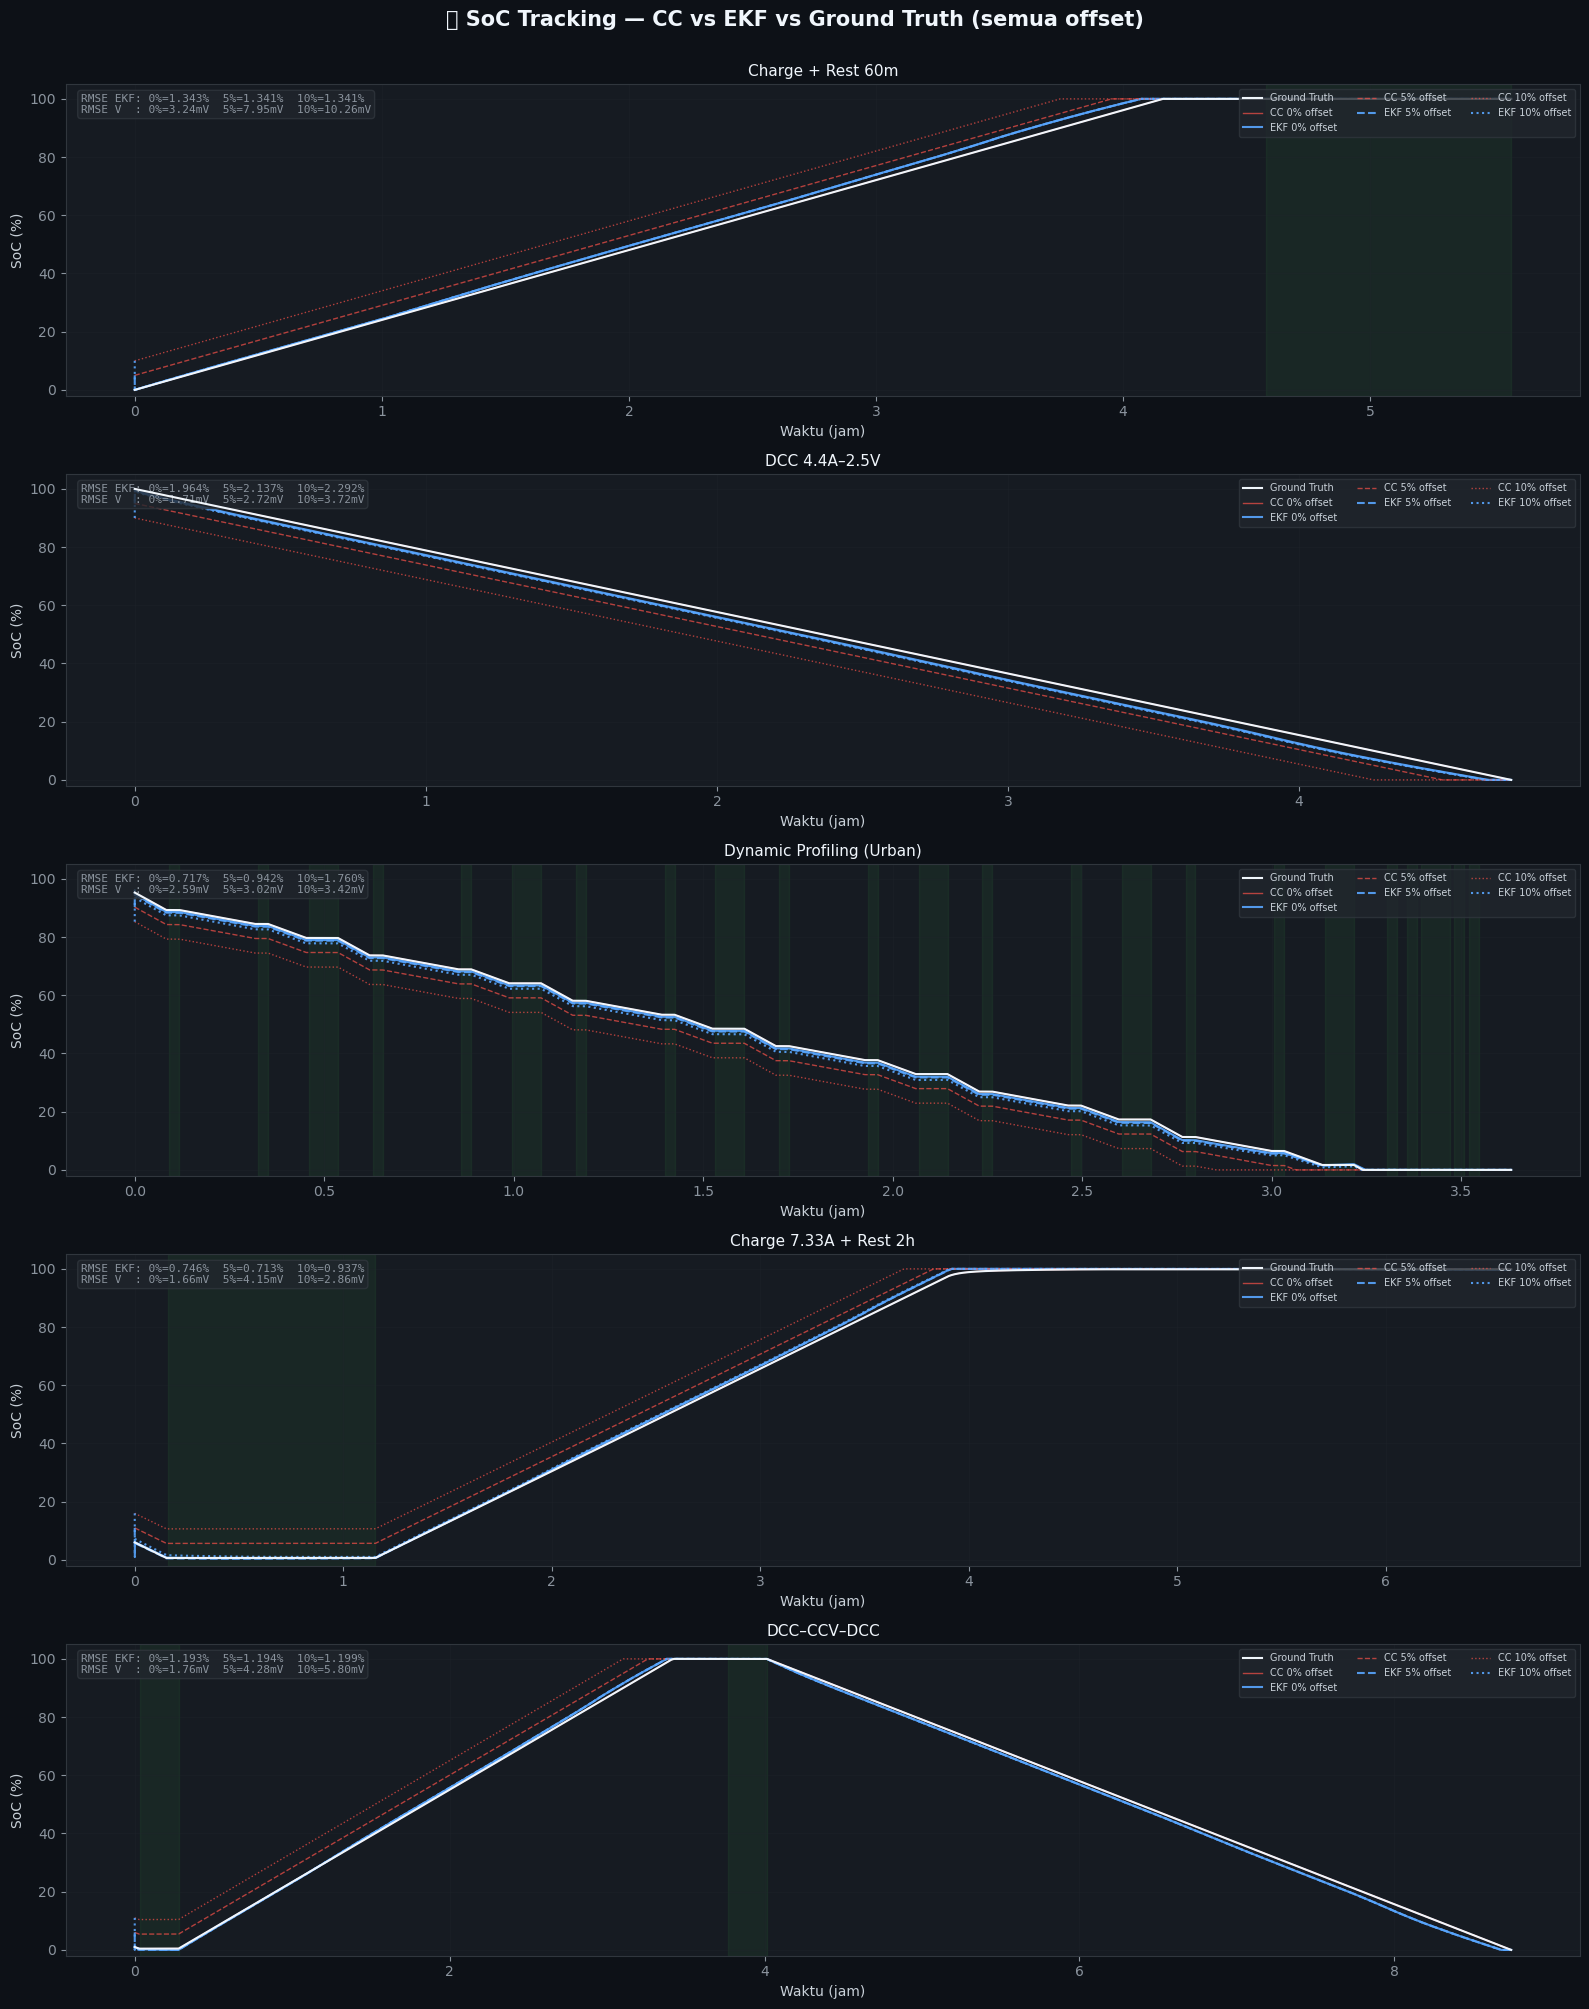

💾 Disimpan: plots\soc_tracking_all.png


In [7]:
# ============================================================
# CELL 7: Plot — SoC Tracking per Dataset (3 offset sekaligus)
# ============================================================

COLORS = {
    'true':  '#f0f6fc',
    'cc':    '#f85149',
    'ekf':   '#58a6ff',
    'rest':  '#3fb950',
}
OFFSET_STYLE = {0.00: '-', 0.05: '--', 0.10: ':'}

n_ds = len(FILENAMES)
fig, axes = plt.subplots(n_ds, 1, figsize=(16, 4 * n_ds), facecolor='#0d1117')
fig.suptitle('🔋 SoC Tracking — CC vs EKF vs Ground Truth (semua offset)',
             fontsize=15, color='#f0f6fc', fontweight='bold', y=1.002)

for ax_idx, fname in enumerate(FILENAMES):
    ax = axes[ax_idx]
    ax.set_facecolor('#161b22')
    ax.grid(True, alpha=0.3)

    # Plot tiap offset
    for off in OFFSETS:
        r = all_results[(fname, off)]
        t_h = r['time'] / 3600  # detik → jam
        ls  = OFFSET_STYLE[off]
        lbl = f'{int(off*100)}% offset'

        if off == 0.0:
            ax.plot(t_h, r['soc_true'] * 100,
                    color=COLORS['true'], lw=1.5, ls='-', label='Ground Truth', zorder=5)

        ax.plot(t_h, r['soc_cc'] * 100,
                color=COLORS['cc'], lw=1.0, ls=ls, alpha=0.7,
                label=f'CC {lbl}')
        ax.plot(t_h, r['soc_ekf'] * 100,
                color=COLORS['ekf'], lw=1.5, ls=ls, alpha=0.9,
                label=f'EKF {lbl}')

        # Tandai confirmed-rest region
        rest_mask = r['rest']
        if rest_mask.any() and off == 0.0:
            rest_changes = np.diff(rest_mask.astype(int), prepend=0)
            starts = t_h[rest_changes == 1]
            ends   = t_h[rest_changes == -1] if (rest_changes == -1).any() else [t_h[-1]]
            for s, e in zip(starts, ends):
                ax.axvspan(s, e, alpha=0.08, color=COLORS['rest'])

    # Metrik text box
    off0_r  = all_results[(fname, 0.00)]
    off5_r  = all_results[(fname, 0.05)]
    off10_r = all_results[(fname, 0.10)]
    info = (
        f"RMSE EKF: 0%={off0_r['rmse_ekf']:.3f}%  5%={off5_r['rmse_ekf']:.3f}%  10%={off10_r['rmse_ekf']:.3f}%\n"
        f"RMSE V  : 0%={off0_r['rmse_v']:.2f}mV  5%={off5_r['rmse_v']:.2f}mV  10%={off10_r['rmse_v']:.2f}mV"
    )
    ax.text(0.01, 0.97, info, transform=ax.transAxes,
            fontsize=8, color='#8b949e', va='top', fontfamily='monospace',
            bbox=dict(facecolor='#21262d', edgecolor='#30363d', alpha=0.8, boxstyle='round,pad=0.3'))

    ax.set_title(DATASET_LABEL[fname], color='#f0f6fc', fontsize=11, pad=6)
    ax.set_ylabel('SoC (%)', color='#c9d1d9')
    ax.set_xlabel('Waktu (jam)', color='#c9d1d9')
    ax.legend(loc='upper right', fontsize=7, ncol=3)
    ax.set_ylim(-2, 105)

plt.tight_layout()
out_path = PLOTS_DIR / 'soc_tracking_all.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'💾 Disimpan: {out_path}')

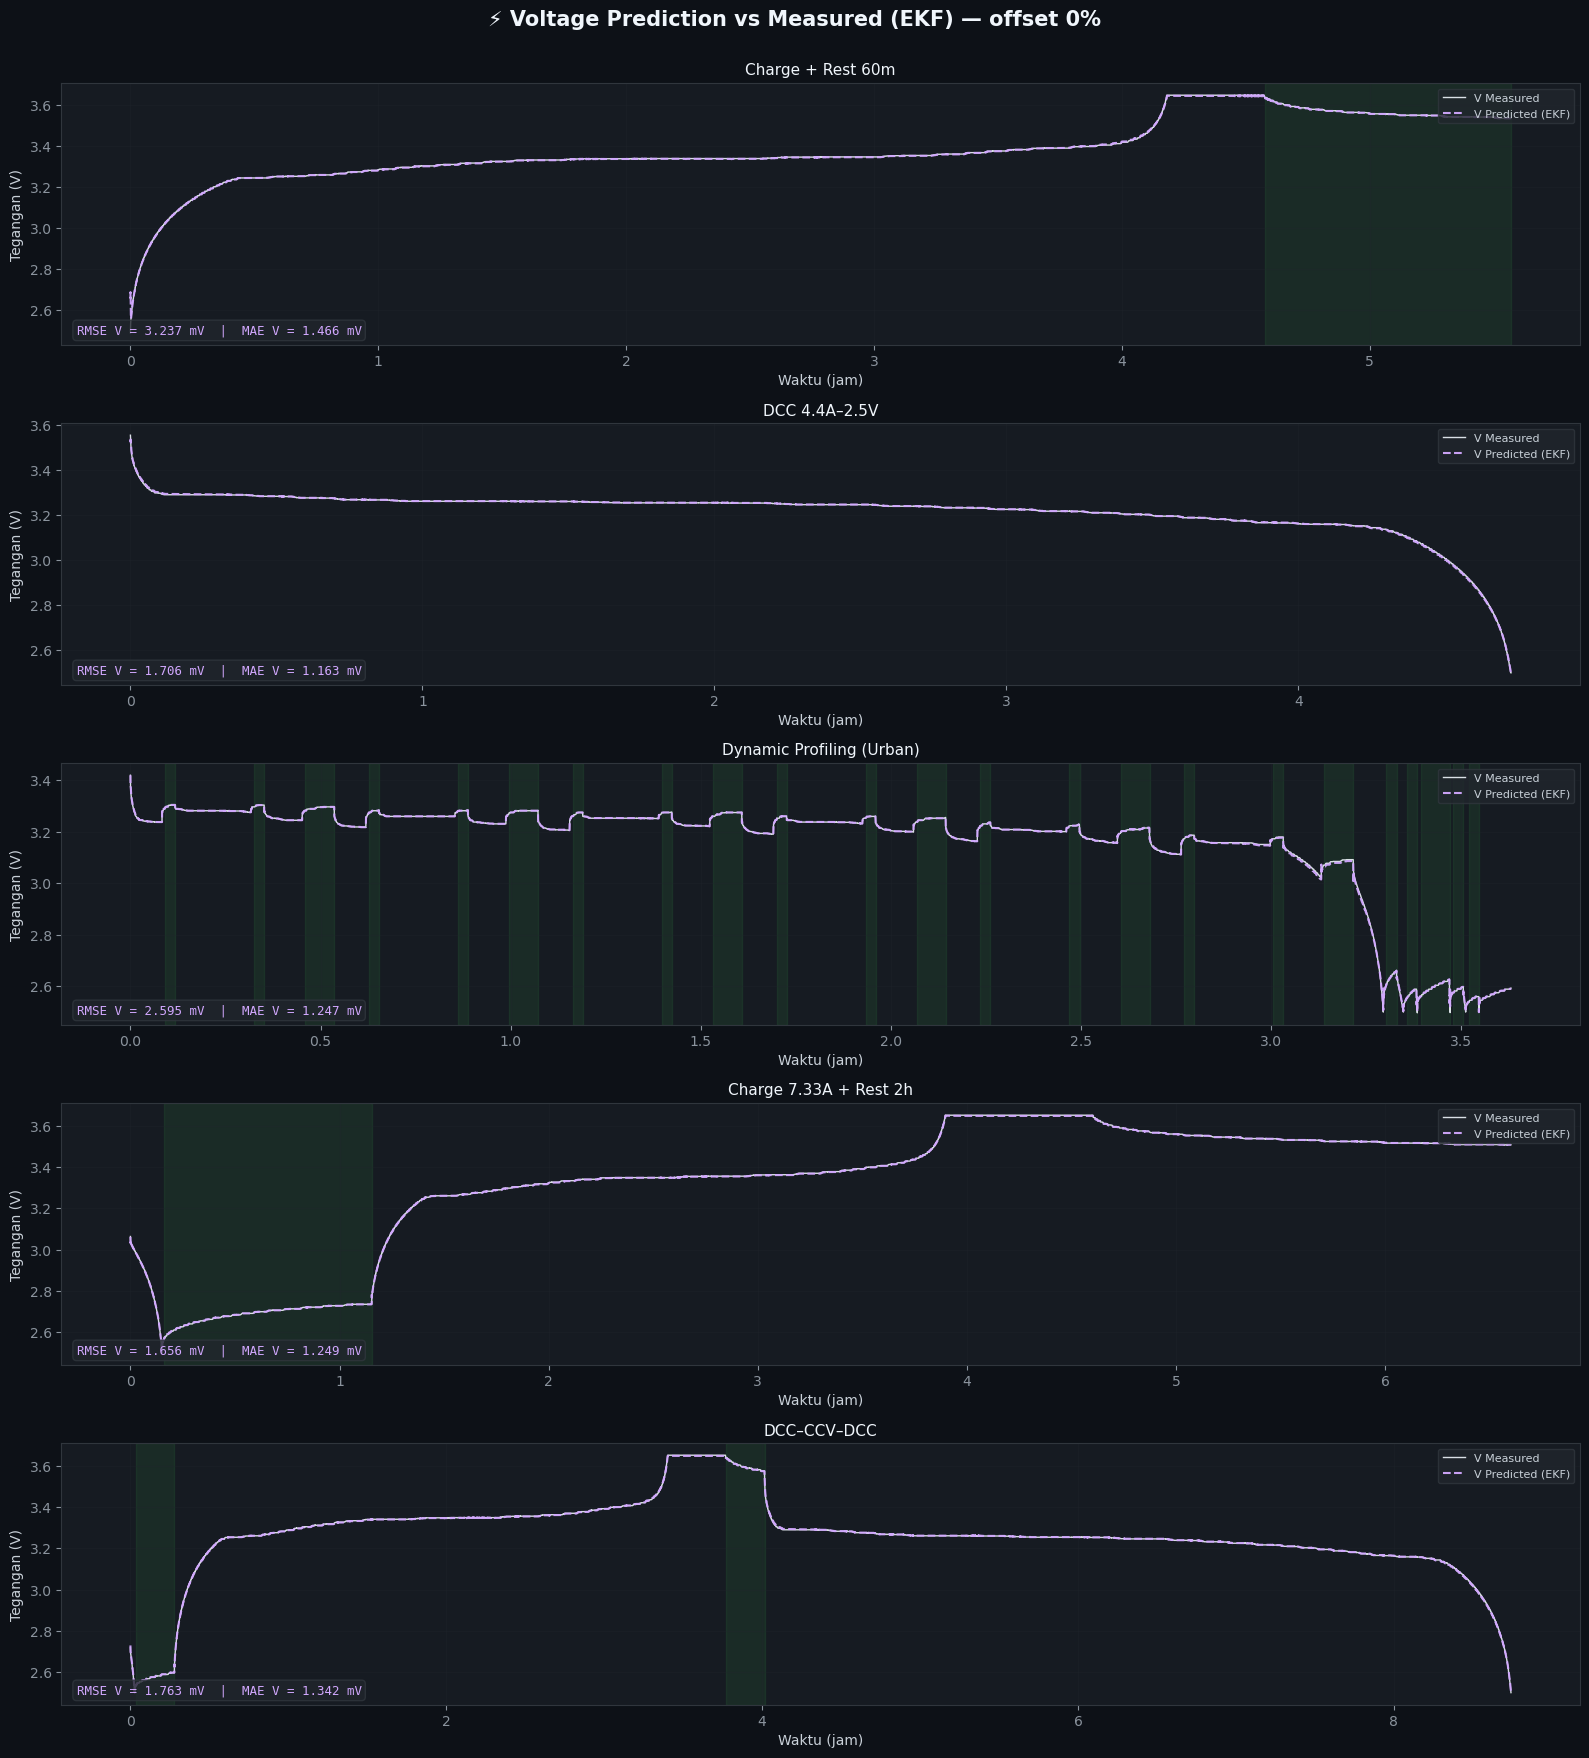

💾 Disimpan: plots\voltage_prediction_all.png


In [8]:
# ============================================================
# CELL 8: Plot — Voltage Prediction vs Measured
# ============================================================

fig, axes = plt.subplots(n_ds, 1, figsize=(16, 3.5 * n_ds), facecolor='#0d1117')
fig.suptitle('⚡ Voltage Prediction vs Measured (EKF) — offset 0%',
             fontsize=15, color='#f0f6fc', fontweight='bold', y=1.002)

for ax_idx, fname in enumerate(FILENAMES):
    r   = all_results[(fname, 0.00)]
    ax  = axes[ax_idx]
    t_h = r['time'] / 3600

    ax.set_facecolor('#161b22')
    ax.grid(True, alpha=0.3)

    ax.plot(t_h, r['v_meas'], color='#f0f6fc', lw=1.0, label='V Measured', alpha=0.9)
    ax.plot(t_h, r['v_pred'], color='#d2a8ff', lw=1.5, ls='--', label='V Predicted (EKF)', alpha=0.95)

    # Highlight rest
    rest_mask = r['rest']
    if rest_mask.any():
        rest_changes = np.diff(rest_mask.astype(int), prepend=0)
        starts = t_h[rest_changes == 1]
        ends   = t_h[rest_changes == -1] if (rest_changes == -1).any() else [t_h[-1]]
        for s, e in zip(starts, ends):
            ax.axvspan(s, e, alpha=0.1, color='#3fb950', label='_nolegend_')

    info = f"RMSE V = {r['rmse_v']:.3f} mV  |  MAE V = {r['mae_v']:.3f} mV"
    ax.text(0.01, 0.03, info, transform=ax.transAxes,
            fontsize=9, color='#d2a8ff', va='bottom', fontfamily='monospace',
            bbox=dict(facecolor='#21262d', edgecolor='#30363d', alpha=0.8, boxstyle='round,pad=0.3'))

    ax.set_title(DATASET_LABEL[fname], color='#f0f6fc', fontsize=11, pad=6)
    ax.set_ylabel('Tegangan (V)', color='#c9d1d9')
    ax.set_xlabel('Waktu (jam)', color='#c9d1d9')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
out_path = PLOTS_DIR / 'voltage_prediction_all.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'💾 Disimpan: {out_path}')

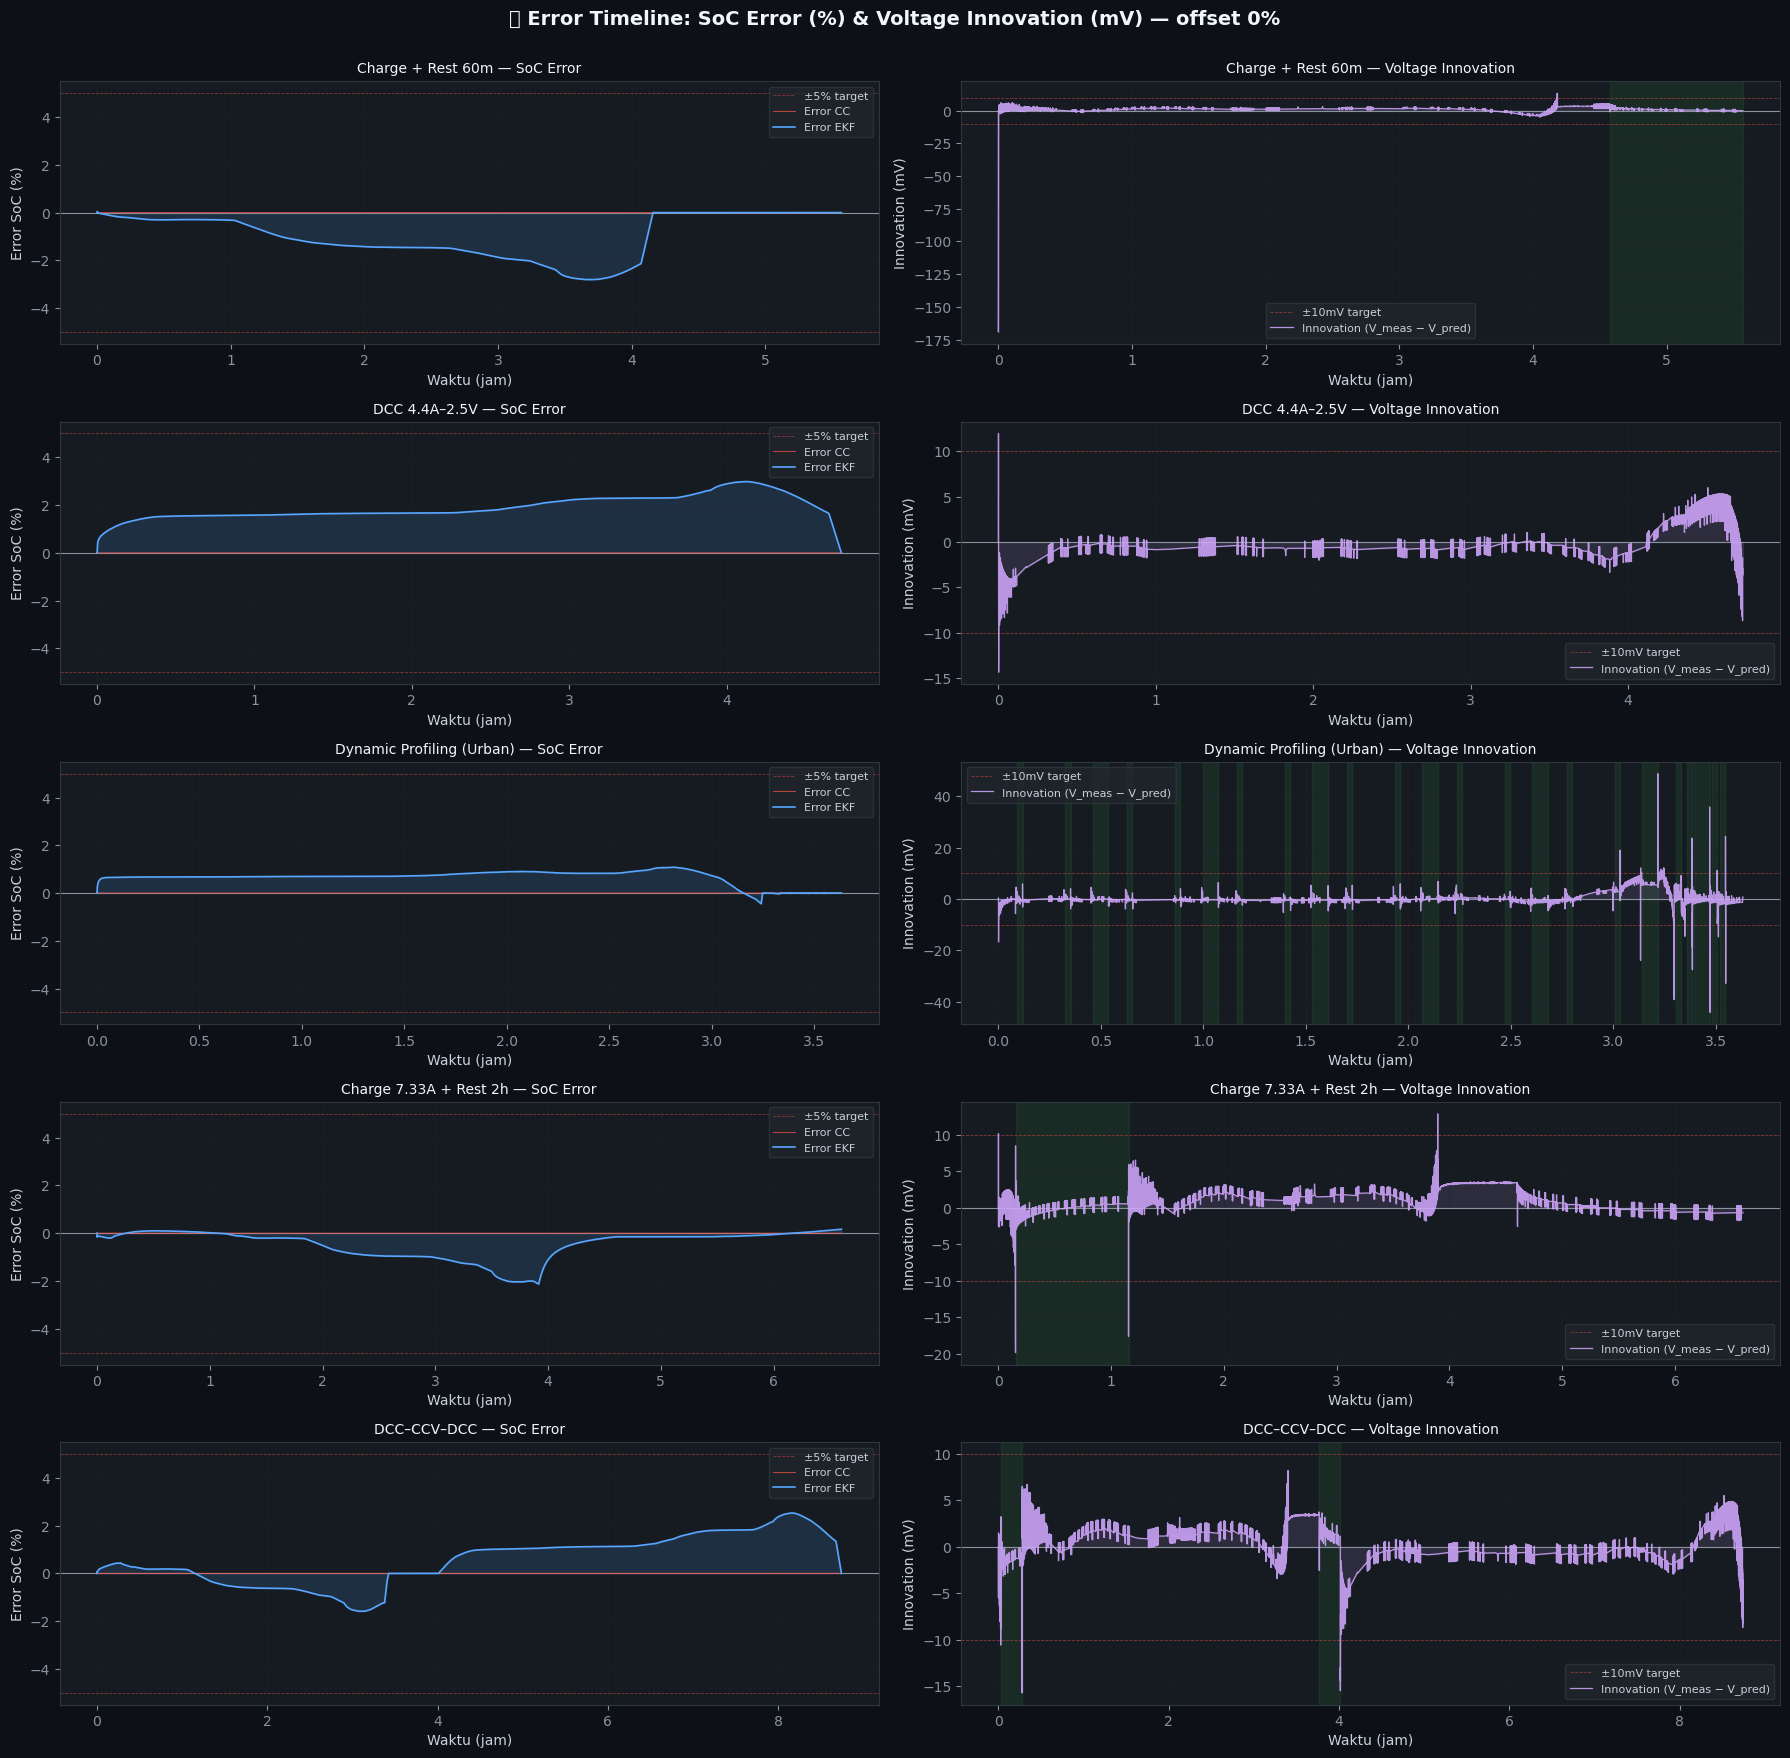

💾 Disimpan: plots\error_timeline_all.png


In [9]:
# ============================================================
# CELL 9: Plot — Error (Innovation) Timeline
# ============================================================

fig, axes = plt.subplots(n_ds, 2, figsize=(18, 3.5 * n_ds), facecolor='#0d1117')
fig.suptitle('📈 Error Timeline: SoC Error (%) & Voltage Innovation (mV) — offset 0%',
             fontsize=14, color='#f0f6fc', fontweight='bold', y=1.002)

for ax_idx, fname in enumerate(FILENAMES):
    r   = all_results[(fname, 0.00)]
    t_h = r['time'] / 3600
    err_cc_pct  = (r['soc_true'] - r['soc_cc'])  * 100
    err_ekf_pct = (r['soc_true'] - r['soc_ekf']) * 100
    innov_mv    = r['innov'] * 1000

    # SoC Error
    ax_soc = axes[ax_idx, 0]
    ax_soc.set_facecolor('#161b22')
    ax_soc.grid(True, alpha=0.3)
    ax_soc.axhline(0,  color='#8b949e', lw=0.8, ls='-')
    ax_soc.axhline( 5, color='#f85149', lw=0.6, ls='--', alpha=0.5, label='±5% target')
    ax_soc.axhline(-5, color='#f85149', lw=0.6, ls='--', alpha=0.5)
    ax_soc.plot(t_h, err_cc_pct,  color=COLORS['cc'],  lw=0.8, alpha=0.7, label='Error CC')
    ax_soc.plot(t_h, err_ekf_pct, color=COLORS['ekf'], lw=1.2, label='Error EKF')
    ax_soc.fill_between(t_h, err_ekf_pct, 0, alpha=0.15, color=COLORS['ekf'])
    ax_soc.set_title(f"{DATASET_LABEL[fname]} — SoC Error", color='#f0f6fc', fontsize=10)
    ax_soc.set_ylabel('Error SoC (%)', color='#c9d1d9')
    ax_soc.set_xlabel('Waktu (jam)', color='#c9d1d9')
    ax_soc.legend(fontsize=8)

    # Voltage Innovation
    ax_v = axes[ax_idx, 1]
    ax_v.set_facecolor('#161b22')
    ax_v.grid(True, alpha=0.3)
    ax_v.axhline(0,   color='#8b949e', lw=0.8)
    ax_v.axhline( 10, color='#f85149', lw=0.6, ls='--', alpha=0.5, label='±10mV target')
    ax_v.axhline(-10, color='#f85149', lw=0.6, ls='--', alpha=0.5)
    ax_v.plot(t_h, innov_mv, color='#d2a8ff', lw=0.9, alpha=0.85, label='Innovation (V_meas − V_pred)')
    ax_v.fill_between(t_h, innov_mv, 0, alpha=0.12, color='#d2a8ff')

    # Tandai confirmed-rest
    rest_mask = r['rest']
    if rest_mask.any():
        rest_changes = np.diff(rest_mask.astype(int), prepend=0)
        starts = t_h[rest_changes == 1]
        ends   = t_h[rest_changes == -1] if (rest_changes == -1).any() else [t_h[-1]]
        for s, e in zip(starts, ends):
            ax_v.axvspan(s, e, alpha=0.1, color='#3fb950', label='_nolegend_')

    ax_v.set_title(f"{DATASET_LABEL[fname]} — Voltage Innovation", color='#f0f6fc', fontsize=10)
    ax_v.set_ylabel('Innovation (mV)', color='#c9d1d9')
    ax_v.set_xlabel('Waktu (jam)', color='#c9d1d9')
    ax_v.legend(fontsize=8)

plt.tight_layout()
out_path = PLOTS_DIR / 'error_timeline_all.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'💾 Disimpan: {out_path}')

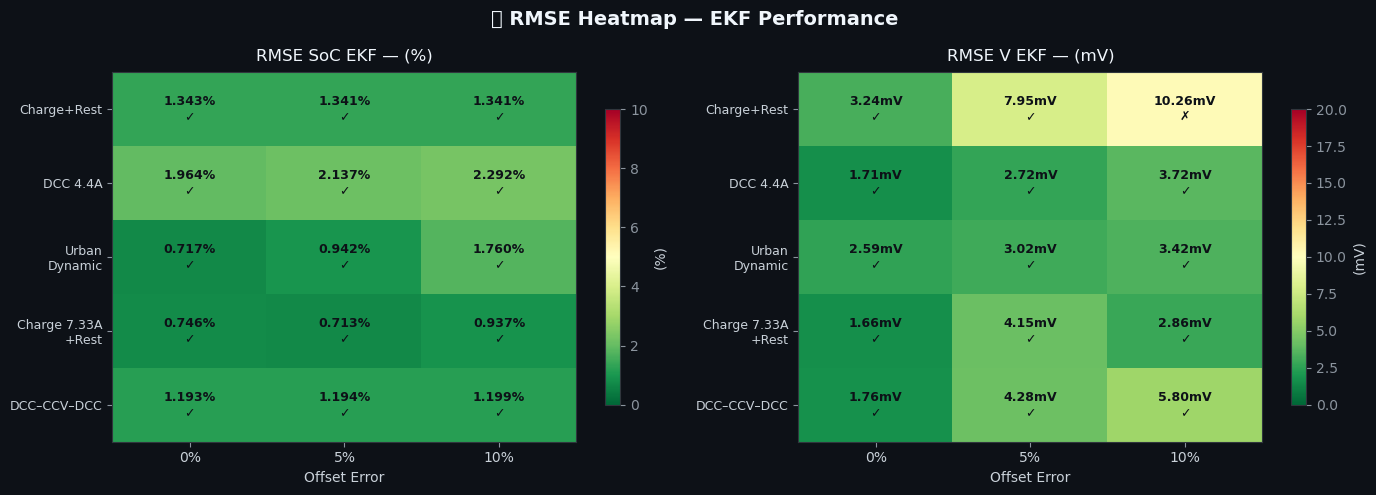

💾 Disimpan: plots\rmse_heatmap.png


In [10]:
# ============================================================
# CELL 10: Plot — RMSE Heatmap (Dataset × Offset)
# ============================================================

import matplotlib.colors as mcolors

labels_short = [
    'Charge+Rest', 'DCC 4.4A', 'Urban\nDynamic', 'Charge 7.33A\n+Rest', 'DCC–CCV–DCC'
]
offset_labels = ['0%', '5%', '10%']

# Build matrices
rmse_soc = np.zeros((len(FILENAMES), len(OFFSETS)))
rmse_v   = np.zeros((len(FILENAMES), len(OFFSETS)))
for i, fname in enumerate(FILENAMES):
    for j, off in enumerate(OFFSETS):
        rmse_soc[i, j] = all_results[(fname, off)]['rmse_ekf']
        rmse_v  [i, j] = all_results[(fname, off)]['rmse_v']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')
fig.suptitle('🗺️ RMSE Heatmap — EKF Performance', fontsize=14, color='#f0f6fc', fontweight='bold')

def plot_heatmap(ax, data, title, fmt, cmap_good, threshold):
    ax.set_facecolor('#161b22')
    cmap = plt.cm.RdYlGn_r
    im = ax.imshow(data, cmap=cmap, aspect='auto',
                   vmin=0, vmax=threshold * 2)
    ax.set_xticks(range(len(OFFSETS)))
    ax.set_xticklabels(offset_labels, color='#c9d1d9')
    ax.set_yticks(range(len(FILENAMES)))
    ax.set_yticklabels(labels_short, color='#c9d1d9', fontsize=9)
    ax.set_xlabel('Offset Error', color='#c9d1d9')
    ax.set_title(title, color='#f0f6fc', fontsize=12, pad=8)

    for i in range(len(FILENAMES)):
        for j in range(len(OFFSETS)):
            val = data[i, j]
            txt = fmt.format(val)
            ok  = '✓' if val < threshold else '✗'
            color = '#0d1117' if val < threshold * 1.2 else '#f0f6fc'
            ax.text(j, i, f'{txt}\n{ok}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')

    plt.colorbar(im, ax=ax, shrink=0.8, label=title.split('—')[1].strip())

plot_heatmap(ax1, rmse_soc, 'RMSE SoC EKF — (%)', '{:.3f}%', 'Greens', 5.0)
plot_heatmap(ax2, rmse_v,   'RMSE V EKF — (mV)',  '{:.2f}mV', 'Greens', 10.0)

plt.tight_layout()
out_path = PLOTS_DIR / 'rmse_heatmap.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'💾 Disimpan: {out_path}')

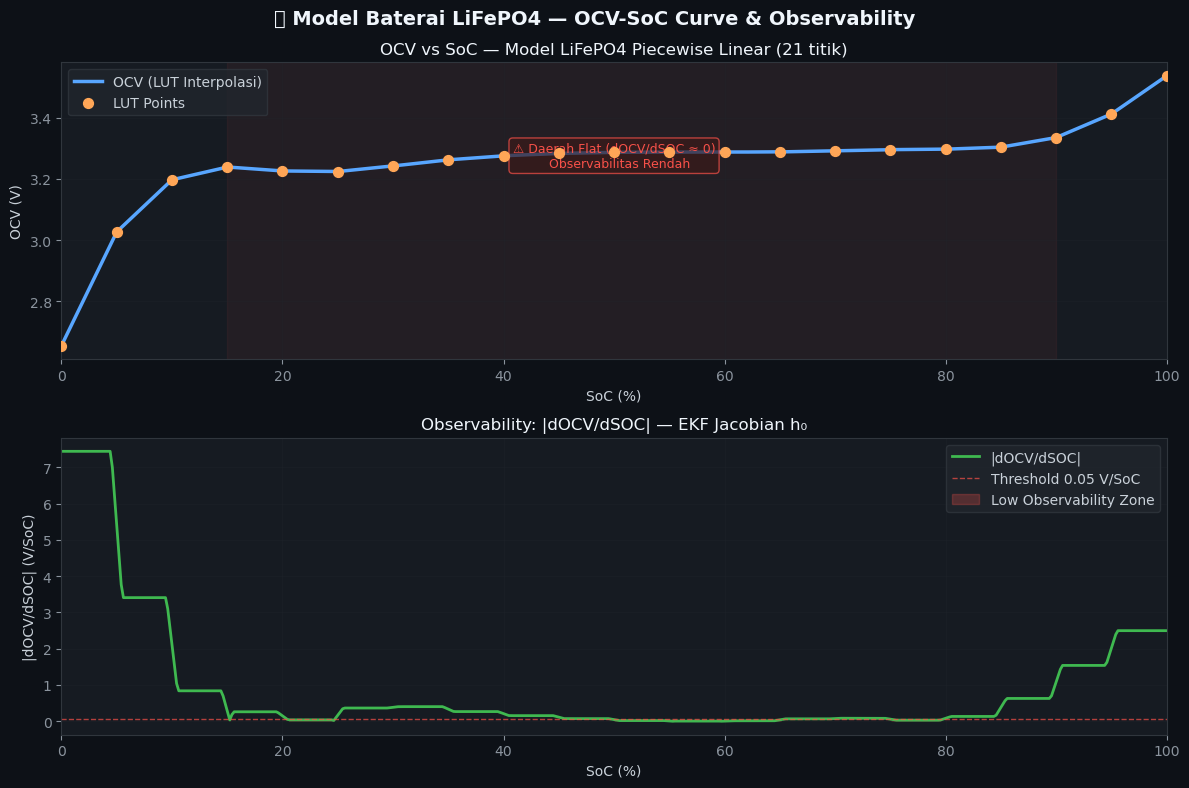

💾 Disimpan: plots\ocv_observability.png


In [11]:
# ============================================================
# CELL 11: Plot — OCV-SoC Curve (LUT) + dOCV/dSOC
# ============================================================

soc_fine = np.linspace(0, 1, 500)
ocv_fine = np.array([get_OCV(s) for s in soc_fine])
dOCV_fine = np.array([get_dOCV_dSOC(s) for s in soc_fine])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), facecolor='#0d1117')
fig.suptitle('📐 Model Baterai LiFePO4 — OCV-SoC Curve & Observability',
             fontsize=14, color='#f0f6fc', fontweight='bold')

# OCV curve
ax1.set_facecolor('#161b22')
ax1.grid(True, alpha=0.3)
ax1.plot(soc_fine * 100, ocv_fine, color='#58a6ff', lw=2.5, label='OCV (LUT Interpolasi)')
ax1.scatter(lut_soc_ocv * 100, lut_ocv_val, color='#ffa657', s=50, zorder=5, label='LUT Points')
ax1.set_xlabel('SoC (%)', color='#c9d1d9')
ax1.set_ylabel('OCV (V)', color='#c9d1d9')
ax1.set_title('OCV vs SoC — Model LiFePO4 Piecewise Linear (21 titik)', color='#f0f6fc')
ax1.legend()
ax1.set_xlim(0, 100)

# Annotate flat region
ax1.axvspan(15, 90, alpha=0.06, color='#f85149')
ax1.text(50, 3.24, '⚠️ Daerah Flat (dOCV/dSOC ≈ 0)\n   Observabilitas Rendah', 
         ha='center', color='#f85149', fontsize=9,
         bbox=dict(facecolor='#3a1a1a', edgecolor='#f85149', alpha=0.7, boxstyle='round,pad=0.3'))

# dOCV/dSOC (observability)
ax2.set_facecolor('#161b22')
ax2.grid(True, alpha=0.3)
ax2.plot(soc_fine * 100, np.abs(dOCV_fine), color='#3fb950', lw=2, label='|dOCV/dSOC|')
ax2.axhline(0.05, color='#f85149', ls='--', lw=1, alpha=0.7, label='Threshold 0.05 V/SoC')
ax2.fill_between(soc_fine * 100, 0, np.abs(dOCV_fine),
                  where=np.abs(dOCV_fine) < 0.05,
                  alpha=0.25, color='#f85149', label='Low Observability Zone')
ax2.set_xlabel('SoC (%)', color='#c9d1d9')
ax2.set_ylabel('|dOCV/dSOC| (V/SoC)', color='#c9d1d9')
ax2.set_title('Observability: |dOCV/dSOC| — EKF Jacobian h₀', color='#f0f6fc')
ax2.legend()
ax2.set_xlim(0, 100)

plt.tight_layout()
out_path = PLOTS_DIR / 'ocv_observability.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'💾 Disimpan: {out_path}')

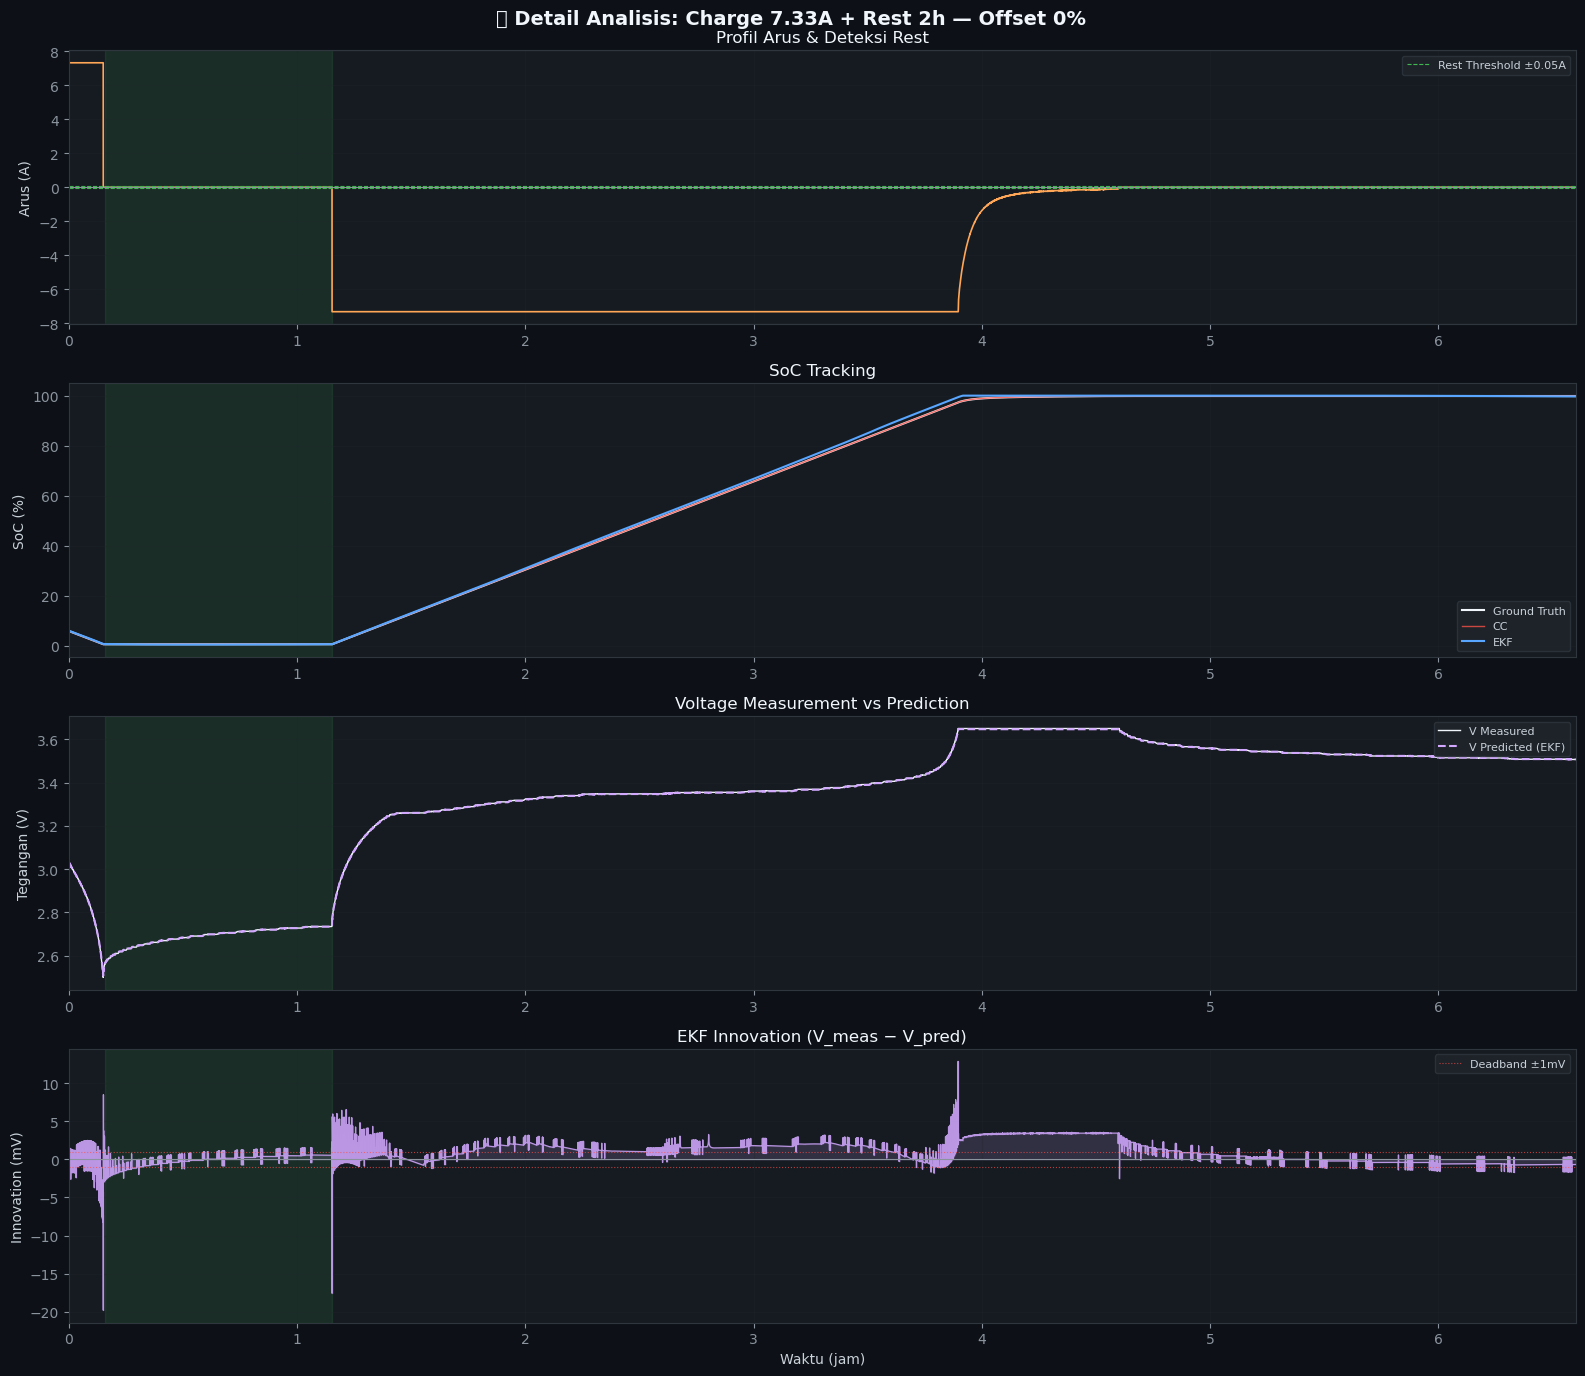

💾 Disimpan: plots\detail_analysis.png


In [12]:
# ============================================================
# CELL 12: Plot — Arus & Rest Detection (satu dataset pilihan)
# ============================================================

# Pilih dataset untuk detail view
SELECTED = 'clean_h-charging_7.33A-rest 2h.csv'

r   = all_results[(SELECTED, 0.00)]
t_h = r['time'] / 3600

fig, axes = plt.subplots(4, 1, figsize=(16, 14), facecolor='#0d1117')
fig.suptitle(f'🔍 Detail Analisis: {DATASET_LABEL[SELECTED]} — Offset 0%',
             fontsize=14, color='#f0f6fc', fontweight='bold')

# Shade rest regions (all panels)
def shade_rest(ax, t_h, rest_mask):
    if rest_mask.any():
        changes = np.diff(rest_mask.astype(int), prepend=0)
        starts  = t_h[changes == 1]
        ends    = t_h[changes == -1] if (changes == -1).any() else [t_h[-1]]
        for s, e in zip(starts, ends):
            ax.axvspan(s, e, alpha=0.12, color='#3fb950', label='_nolegend_')

# Panel 1: Arus
ax = axes[0]
ax.set_facecolor('#161b22'); ax.grid(True, alpha=0.3)
ax.plot(t_h, r['current'], color='#ffa657', lw=1.2)
ax.axhline(0, color='#8b949e', lw=0.8)
ax.axhline(REST_CURRENT_THRESH,  color='#3fb950', lw=0.8, ls='--', label=f'Rest Threshold ±{REST_CURRENT_THRESH}A')
ax.axhline(-REST_CURRENT_THRESH, color='#3fb950', lw=0.8, ls='--')
shade_rest(ax, t_h, r['rest'])
ax.set_ylabel('Arus (A)', color='#c9d1d9')
ax.set_title('Profil Arus & Deteksi Rest', color='#f0f6fc')
ax.legend(fontsize=8)

# Panel 2: SoC
ax = axes[1]
ax.set_facecolor('#161b22'); ax.grid(True, alpha=0.3)
ax.plot(t_h, r['soc_true'] * 100, color='#f0f6fc', lw=1.5, label='Ground Truth')
ax.plot(t_h, r['soc_cc']   * 100, color='#f85149', lw=1.0, alpha=0.8, label='CC')
ax.plot(t_h, r['soc_ekf']  * 100, color='#58a6ff', lw=1.5, label='EKF')
shade_rest(ax, t_h, r['rest'])
ax.set_ylabel('SoC (%)', color='#c9d1d9')
ax.set_title('SoC Tracking', color='#f0f6fc')
ax.legend(fontsize=8)

# Panel 3: Tegangan
ax = axes[2]
ax.set_facecolor('#161b22'); ax.grid(True, alpha=0.3)
ax.plot(t_h, r['v_meas'], color='#f0f6fc', lw=1.0, label='V Measured')
ax.plot(t_h, r['v_pred'], color='#d2a8ff', lw=1.5, ls='--', label='V Predicted (EKF)')
shade_rest(ax, t_h, r['rest'])
ax.set_ylabel('Tegangan (V)', color='#c9d1d9')
ax.set_title('Voltage Measurement vs Prediction', color='#f0f6fc')
ax.legend(fontsize=8)

# Panel 4: Innovation (residual)
ax = axes[3]
ax.set_facecolor('#161b22'); ax.grid(True, alpha=0.3)
innov_mv = r['innov'] * 1000
ax.plot(t_h, innov_mv, color='#d2a8ff', lw=0.9, alpha=0.85)
ax.fill_between(t_h, innov_mv, 0, alpha=0.15, color='#d2a8ff')
ax.axhline(0,  color='#8b949e', lw=0.8)
ax.axhline( DEADBAND_V*1000, color='#f85149', lw=0.8, ls=':', alpha=0.7, label=f'Deadband ±{DEADBAND_V*1000:.0f}mV')
ax.axhline(-DEADBAND_V*1000, color='#f85149', lw=0.8, ls=':', alpha=0.7)
shade_rest(ax, t_h, r['rest'])
ax.set_xlabel('Waktu (jam)', color='#c9d1d9')
ax.set_ylabel('Innovation (mV)', color='#c9d1d9')
ax.set_title('EKF Innovation (V_meas − V_pred)', color='#f0f6fc')
ax.legend(fontsize=8)

# Share x-axis
for ax in axes:
    ax.set_xlim(t_h[0], t_h[-1])

plt.tight_layout()
out_path = PLOTS_DIR / 'detail_analysis.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'💾 Disimpan: {out_path}')

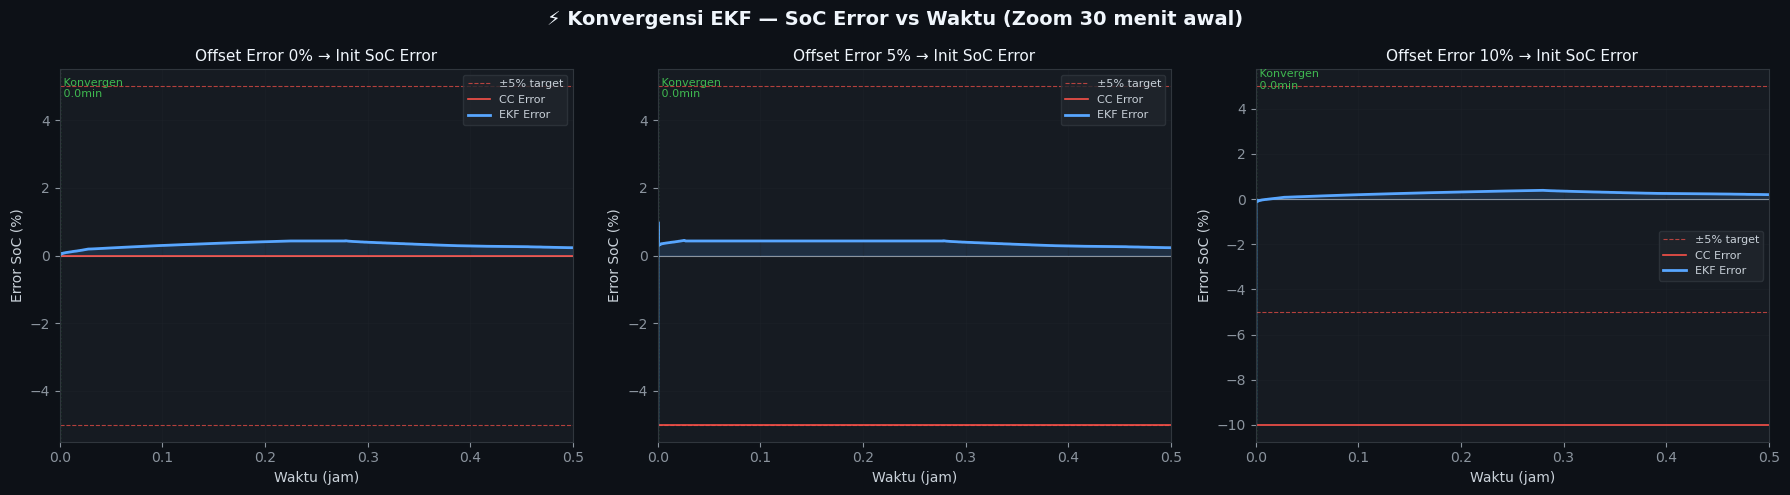

💾 Disimpan: plots\ekf_convergence.png


In [13]:
# ============================================================
# CELL 13: Plot — Konvergensi EKF (SoC Error vs Waktu, zoom awal)
# ============================================================

CONV_FILE = 'clean_h-DCC_4.4A_2.5V-CCV_6.6_3.65V-DCC_4.4A_2.5V.csv'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0d1117')
fig.suptitle('⚡ Konvergensi EKF — SoC Error vs Waktu (Zoom 30 menit awal)',
             fontsize=14, color='#f0f6fc', fontweight='bold')

for ax_idx, off in enumerate(OFFSETS):
    r    = all_results[(CONV_FILE, off)]
    ax   = axes[ax_idx]
    t_h  = r['time'] / 3600
    mask = t_h <= 0.5  # 30 menit

    err_cc_pct  = (r['soc_true'] - r['soc_cc'])  * 100
    err_ekf_pct = (r['soc_true'] - r['soc_ekf']) * 100

    ax.set_facecolor('#161b22')
    ax.grid(True, alpha=0.3)
    ax.axhline(0,  color='#8b949e', lw=0.8)
    ax.axhline( 5, color='#f85149', lw=0.8, ls='--', alpha=0.7, label='±5% target')
    ax.axhline(-5, color='#f85149', lw=0.8, ls='--', alpha=0.7)
    ax.plot(t_h[mask], err_cc_pct[mask],  color=COLORS['cc'],  lw=1.2, label='CC Error')
    ax.plot(t_h[mask], err_ekf_pct[mask], color=COLORS['ekf'], lw=2.0, label='EKF Error')
    ax.fill_between(t_h[mask], err_ekf_pct[mask], 0, alpha=0.15, color=COLORS['ekf'])

    # Annotate konvergensi
    ekf_conv_idx = np.where(np.abs(err_ekf_pct) < 5.0)[0]
    if len(ekf_conv_idx) > 0:
        conv_t = t_h[ekf_conv_idx[0]] * 60  # menit
        ax.axvline(t_h[ekf_conv_idx[0]], color='#3fb950', lw=1.0, ls=':', alpha=0.7)
        ax.text(t_h[ekf_conv_idx[0]], ax.get_ylim()[1] * 0.85 if ax.get_ylim()[1] else 10,
                f' Konvergen\n {conv_t:.1f}min', color='#3fb950', fontsize=8)

    ax.set_title(f'Offset Error {int(off*100)}% → Init SoC Error', color='#f0f6fc', fontsize=11)
    ax.set_xlabel('Waktu (jam)', color='#c9d1d9')
    ax.set_ylabel('Error SoC (%)', color='#c9d1d9')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 0.5)

plt.tight_layout()
out_path = PLOTS_DIR / 'ekf_convergence.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'💾 Disimpan: {out_path}')

In [14]:
# ============================================================
# CELL 14: Ringkasan Akhir — Print Tabel + Verdict
# ============================================================

print('=' * 90)
print('  📊  RINGKASAN HASIL SIMULASI PiL — CC vs EKF')
print('=' * 90)
print(f'{"Dataset":<38} {"Offset":>7} {"RMSE CC":>9} {"RMSE EKF":>10} {"RMSE V":>10}  Target')
print('-' * 90)

all_ok = True
for off in OFFSETS:
    for fname in FILENAMES:
        r  = all_results[(fname, off)]
        ok_soc = r['rmse_ekf'] < 5.0
        ok_v   = r['rmse_v']   < 10.0
        ok     = ok_soc and ok_v
        all_ok = all_ok and ok
        icon   = '✅' if ok else ('⚠️ ' if ok_soc or ok_v else '❌')
        print(f'{r["label"]:<38} {int(off*100):>6}%  {r["rmse_cc"]:>8.4f}%  {r["rmse_ekf"]:>8.4f}%  {r["rmse_v"]:>8.3f}mV  {icon}')

print('=' * 90)
if all_ok:
    print('  🎉  SEMUA TARGET TERCAPAI: RMSE SoC EKF < 5%  &  RMSE V EKF < 10mV  ✅')
else:
    print('  ⚠️   Beberapa dataset belum memenuhi target — perlu re-tuning.')
print('=' * 90)
print(f'\n  Parameter EKF yang digunakan:')
print(f'    Q_NOISE_00 = {Q_NOISE_00:.1e}   Q_NOISE_11 = {Q_NOISE_11:.1e}')
print(f'    R_BASE     = {R_BASE}   R_REST     = {R_REST}')
print(f'    Soft Deadband = {DEADBAND_V*1000:.0f} mV   REST_SETTLE = {REST_SETTLE_S}s')
print(f'    P_init[0,0] = offset×50 + 0.01   P_init[1,1] = 0.001')
print(f'    Jacobian h₀ = dOCV/dSOC + 1e-4 (no hard floor)')
print(f'\n📁 Semua plot tersimpan di folder: {PLOTS_DIR.resolve()}')

  📊  RINGKASAN HASIL SIMULASI PiL — CC vs EKF
Dataset                                 Offset   RMSE CC   RMSE EKF     RMSE V  Target
------------------------------------------------------------------------------------------
Charge + Rest 60m                           0%    0.0000%    1.3426%     3.237mV  ✅
DCC 4.4A–2.5V                               0%    0.0000%    1.9642%     1.706mV  ✅
Dynamic Profiling (Urban)                   0%    0.0000%    0.7175%     2.595mV  ✅
Charge 7.33A + Rest 2h                      0%    0.0000%    0.7455%     1.656mV  ✅
DCC–CCV–DCC                                 0%    0.0000%    1.1926%     1.763mV  ✅
Charge + Rest 60m                           5%    4.2479%    1.3414%     7.945mV  ✅
DCC 4.4A–2.5V                               5%    4.9151%    2.1367%     2.721mV  ✅
Dynamic Profiling (Urban)                   5%    4.6232%    0.9419%     3.017mV  ✅
Charge 7.33A + Rest 2h                      5%    3.8388%    0.7132%     4.147mV  ✅
DCC–CCV–DCC         